In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
import os
os.listdir()

['customer_segmentation.csv', 'customer_segmentation.ipynb']

In [4]:
df=pd.read_csv("customer_segmentation.csv")

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
import seaborn as sns
import sklearn
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [12]:
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [13]:
df['Dt_Customer'].dtype

dtype('O')

In [14]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

In [15]:
df['Dt_Customer'].dtype

dtype('<M8[ns]')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [17]:
df['Age']=2026-df["Year_Birth"]

In [18]:
df['Age']

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2216, dtype: int64

In [19]:
df['Total_children']=df['Kidhome']+df['Teenhome']

In [20]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children'],
      dtype='object')

In [21]:
spend_cols=['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']

In [22]:
df['Total_spends']=df[spend_cols].sum(axis=1)

In [23]:
df["Total_spends"]

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_spends, Length: 2216, dtype: int64

In [24]:
df["Customer_Since"]=(pd.Timestamp("today")-df['Dt_Customer']).dt.days

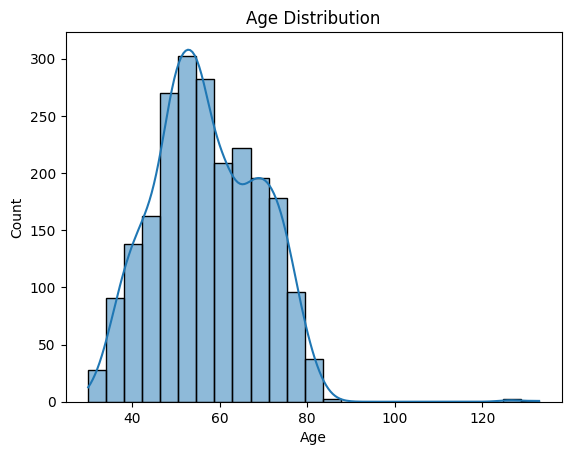

In [25]:
sns.histplot(df['Age'],bins=25,kde=True)
plt.title("Age Distribution")
plt.show()

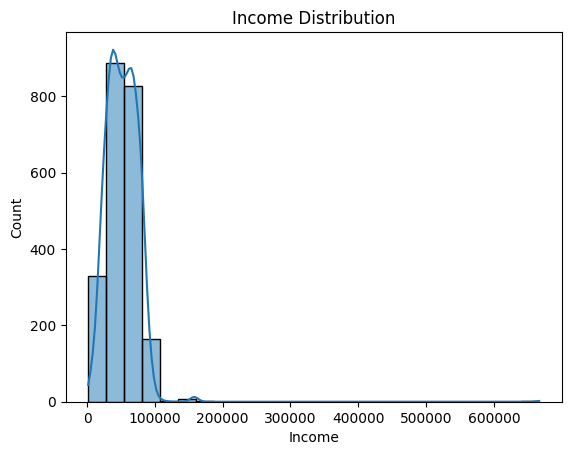

In [26]:
sns.histplot(df["Income"],bins=25,kde=True)
plt.title("Income Distribution")
plt.show()

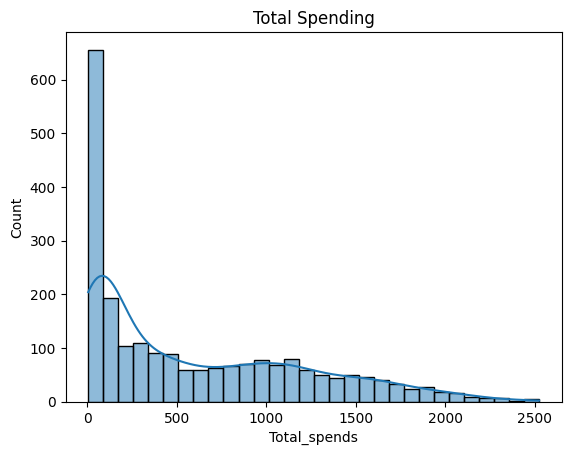

In [27]:
sns.histplot(df["Total_spends"],bins=30,kde=True)
plt.title("Total Spending")
plt.show()

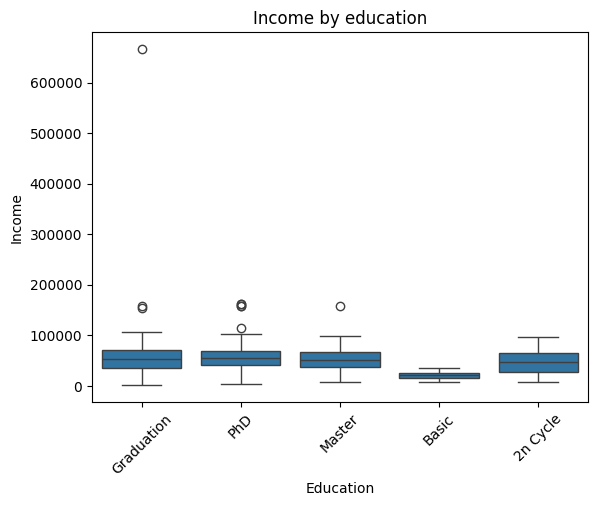

In [28]:
sns.boxplot(x="Education",y="Income",data=df)
plt.xticks(rotation=45)
plt.title("Income by education")
plt.show()

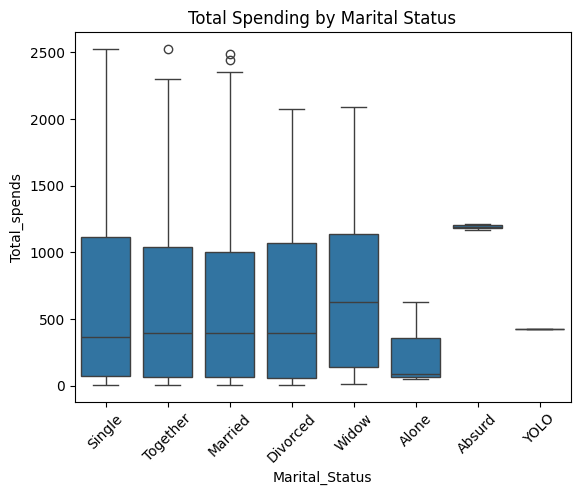

In [29]:
#df.columns
sns.boxplot(x="Marital_Status",y="Total_spends",data=df)
plt.xticks(rotation=45)
plt.title("Total Spending by Marital Status")
plt.show()

In [30]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_spends', 'Customer_Since'],
      dtype='object')

In [31]:
corr=df[['Income',"Age","Recency","Total_spends","NumWebPurchases","NumStorePurchases"]].corr()

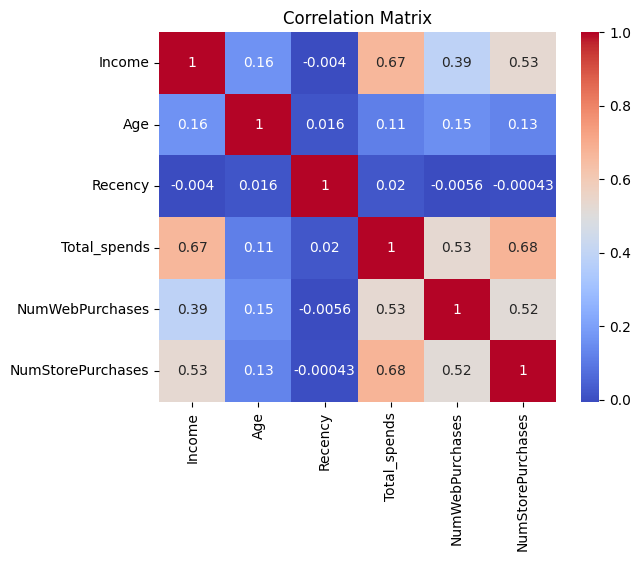

In [32]:
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [33]:
pivot_income=df.pivot_table(values="Income",index="Education",columns="Marital_Status",aggfunc='mean')

In [34]:
pivot_income


Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


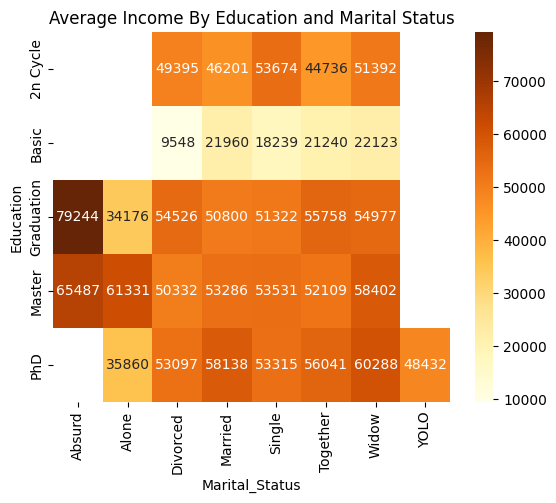

In [35]:
sns.heatmap(pivot_income,annot=True,fmt='.0f',cmap='YlOrBr')
plt.title("Average Income By Education and Marital Status")
plt.show()

In [36]:
group1=df.groupby("Education")['Total_spends'].mean().sort_values(ascending=True)

In [37]:
group1

Education
Basic          81.796296
2n Cycle      494.930000
Master        609.767123
Graduation    621.686380
PhD           676.733888
Name: Total_spends, dtype: float64

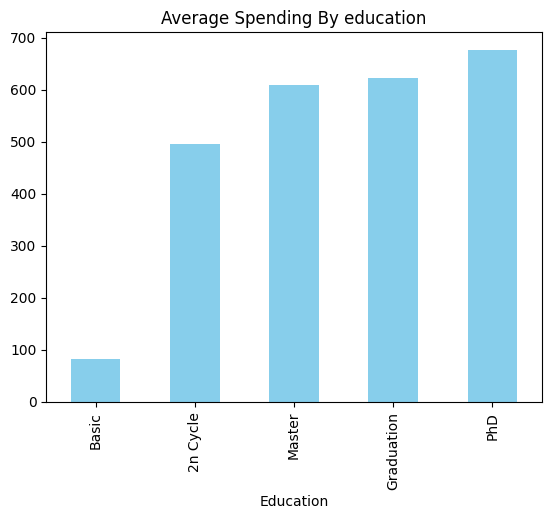

In [38]:
group1.plot(kind='bar',color="skyblue")
plt.title("Average Spending By education")
plt.show()

In [39]:
df["AcceptedAny"]=df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]].sum(axis=1)

In [40]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [41]:
df["AcceptedAny"]=df["AcceptedAny"].apply(lambda x: 1 if x>0 else 0)

In [42]:
df["AcceptedAny"].unique()

array([1, 0])

In [43]:
group2=df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)

In [44]:
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

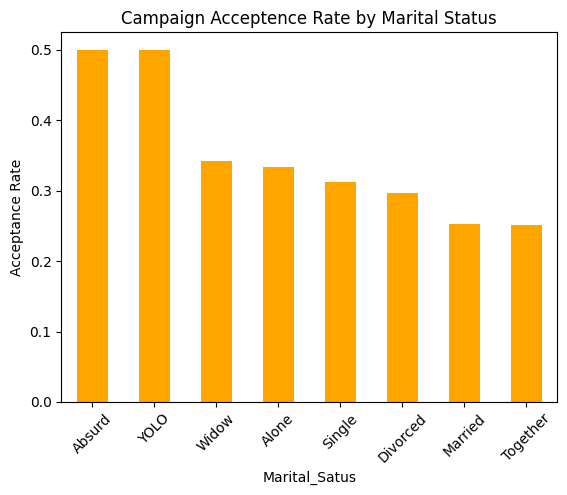

In [45]:
group2.plot(kind='bar',color='orange')
plt.title("Campaign Acceptence Rate by Marital Status")
plt.ylabel("Acceptance Rate")
plt.xlabel("Marital_Satus")
plt.xticks(rotation=45)
plt.show()

In [46]:
bins=[18,30,40,50,60,70,90]
labels=['18-29','30-39','40-49','50-59','60-69','70+']

In [47]:
df['AgeGroup']=pd.cut(df['Age'],bins=bins,labels=labels)

In [48]:
group3=df.groupby("AgeGroup")["Income"].mean()

C:\Users\MAINAK\AppData\Local\Temp\ipykernel_2140\1495347196.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3=df.groupby("AgeGroup")["Income"].mean()


In [49]:
group3

AgeGroup
18-29    10960.500000
30-39    47905.475676
40-49    48057.587649
50-59    50479.321534
60-69    55980.030928
70+      58767.083102
Name: Income, dtype: float64

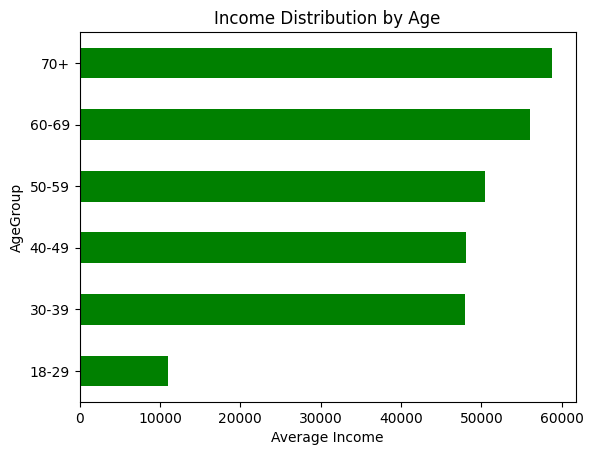

In [50]:
group3.plot(kind="barh",color="green")
plt.title("Income Distribution by Age")
plt.xlabel("Average Income")
plt.show()

In [51]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_spends', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [52]:
features=["Age","Income","Total_spends","NumWebPurchases","NumStorePurchases","NumWebVisitsMonth","Recency"]

In [53]:
X=df[features].copy()

In [54]:
scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

In [55]:
wcss=[]

for k in range(2,10):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [56]:
wcss

[10218.620143748783,
 9007.786818672808,
 8395.850455332482,
 7568.537234972471,
 7078.718653978745,
 6877.127753962412,
 6410.244096072211,
 5895.373307152689]

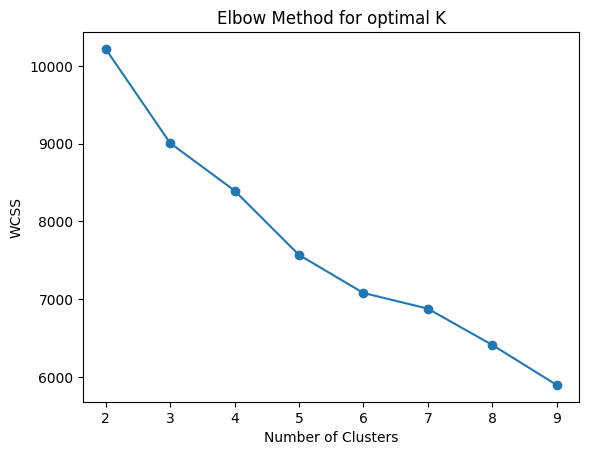

In [57]:
plt.plot(range(2,10),wcss,marker='o')
plt.title("Elbow Method for optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [68]:
kmeans=KMeans(n_clusters=5)
df['Cluster']=kmeans.fit_predict(X_scaled)

In [69]:
df["Cluster"]

0       1
1       2
2       3
3       2
4       1
       ..
2235    3
2236    1
2237    4
2238    3
2239    2
Name: Cluster, Length: 2216, dtype: int32

In [70]:
cluster_summary=df.groupby("Cluster")[features].mean()

In [72]:
cluster_summary

,Age,Income,Total_spends,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,71.245902,72860.439344,1157.632787,4.380328,8.065574,2.550820,54.078689
1,61.255072,51314.855072,533.556522,6.150725,5.759420,6.655072,63.597101
2,53.652822,33107.725240,85.411076,1.916933,3.071353,6.514377,47.366347
3,59.820261,63742.130719,998.663399,7.683007,9.035948,5.748366,28.640523
4,47.233645,78693.470405,1315.676012,4.498442,8.595016,2.607477,52.760125


In [71]:
df["Cluster"].value_counts()

Cluster
2    939
1    345
4    321
3    306
0    305
Name: count, dtype: int64

In [63]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
pca_data=pca.fit_transform(X_scaled)
df['PCA1'],df['PCA2'],df["PCA3"]=pca_data[:,0],pca_data[:,1],pca_data[:,2]

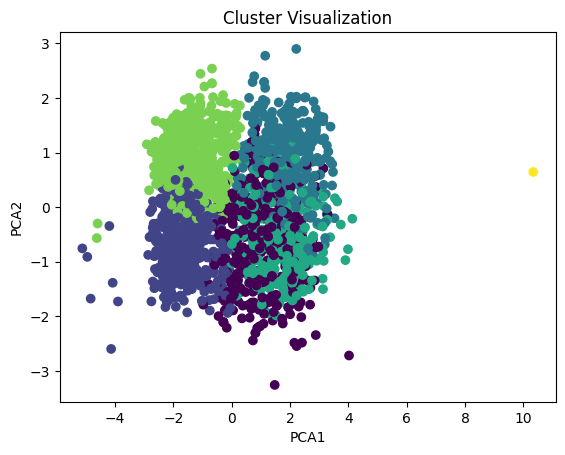

In [64]:
plt.scatter(df['PCA1'],df['PCA2'],c=df["Cluster"],cmap='viridis')
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Cluster Visualization")
plt.show()


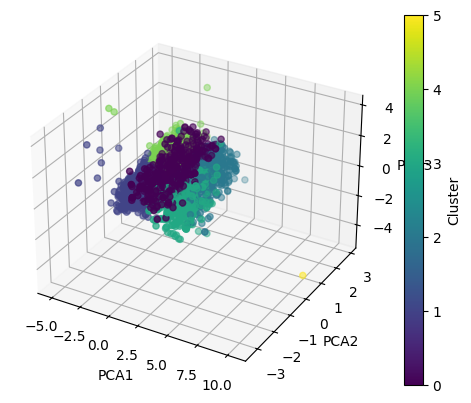

In [65]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['PCA1'], df['PCA2'], df['PCA3'],
                     c=df['Cluster'], cmap='viridis')

fig.colorbar(scatter, label="Cluster")

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')

plt.show()

In [66]:
!pip install nbformat

In [67]:
import plotly.express as px
# import plotly.io as pio
# pio.renderers.default = "browser"

fig = px.scatter_3d(
    df,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='Cluster',
    title='3D Cluster Visualization'
)

fig.show()

In [73]:
import joblib

joblib.dump(kmeans,"kmeans.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']